In [10]:
import model_utils as model_utils
import pandas as pd
import numpy as np

In [11]:
df = pd.read_csv(
    "Allsharkteeth.csv", 
    skipinitialspace = True
)
data_frame = df.copy(deep=True)

# Dropping cusplet measurements and non-shark data
cusplet_cols = [
    "LCH",
    "LCW",
    "CDS"
]

data_frame = data_frame.drop(columns=cusplet_cols)
data_frame = data_frame[data_frame["Taxon"] != "Onchopristis dunklei"]

measurement_cols = [
    "BCW",
    "CH",
    "DCL",
    "IDCL",
    "IMCL",
    "MCL",
    "PCH",
    "PCW",
    "RH",
    "RW",
    "TH",
    "DS",
    "RA"
]

# Replacing 0 values with NaN for measurement columns
data_frame[measurement_cols] = data_frame[measurement_cols].replace(0, np.nan)

# Defining prediciton target and predictors
target = "DS"
predictors = [col for col in measurement_cols if col != target]

In [12]:
model, predictions, y = model_utils.linear_model(data_frame, target, predictors)

ValueError: The truth value of a DataFrame is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

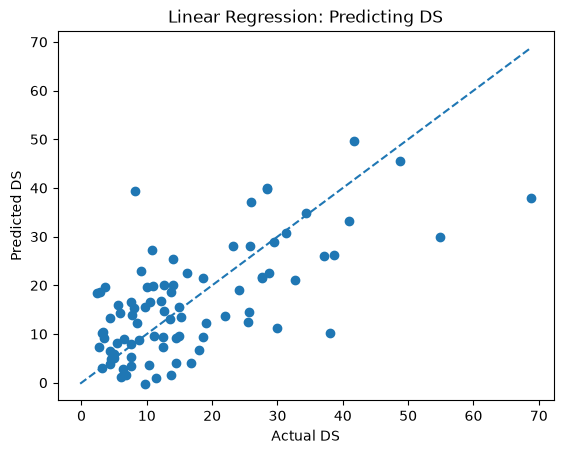

In [ ]:
model_utils.plot_model(target, predictions, y)